# Day 2 Statistics essentials

**Today's task:** mean, variance, distributions, correlation, conditional probability, Bayes intuition.

In [10]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  # reproducibility

print("Mean: The average value found by adding all numbers and dividing by the total count.\nVariance: A measure of how far spread out numbers are from their average value.\nDistributions: A chart or list showing how often different values appear in a dataset.\nCorrelation: A number that shows if and how strongly two things move together.\nConditional probability: The chance of an event happening based on the condition that another event already happened.\nBayes intuition: Updating your previous belief with new evidence to find the correct updated chance.")

Mean: The average value found by adding all numbers and dividing by the total count.
Variance: A measure of how far spread out numbers are from their average value.
Distributions: A chart or list showing how often different values appear in a dataset.
Correlation: A number that shows if and how strongly two things move together.
Conditional probability: The chance of an event happening based on the condition that another event already happened.
Bayes intuition: Updating your previous belief with new evidence to find the correct updated chance.


In [7]:
scores = np.array([62, 75, 88, 91, 55, 70, 83, 95, 60, 78])

# mean
mean_manual = sum(scores) / len(scores)
mean_numpy = np.mean(scores)

# variance
variance_manual = sum((x - mean_manual) ** 2 for x in scores) / len(scores)
variance_numpy = np.var(scores)

print(f"Mean (manual): {mean_manual:.2f}   | Mean (numpy): {mean_numpy:.2f}")
print(f"Variance (manual): {variance_manual:.2f} | Variance (numpy): {variance_numpy:.2f}")

#Standard deviation
print(f"Standard deviation: {np.std(scores):.2f}")

Mean (manual): 75.70   | Mean (numpy): 75.70
Variance (manual): 171.21 | Variance (numpy): 171.21
Standard deviation: 13.08


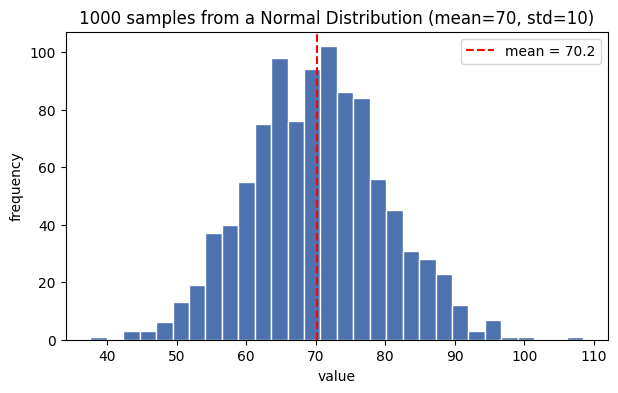

In [3]:
sample = np.random.normal(loc=70, scale=10, size=1000)  # loc=mean, scale=std dev

plt.figure(figsize=(7, 4))
plt.hist(sample, bins=30, color="#4C72B0", edgecolor="white")
plt.axvline(sample.mean(), color="red", linestyle="--", label=f"mean = {sample.mean():.1f}")
plt.title("1000 samples from a Normal Distribution (mean=70, std=10)")
plt.xlabel("value")
plt.ylabel("frequency")
plt.legend()
plt.show()


Now — correlation. Made up a "study hours vs exam score".

**Positive correlation (+):** Both things go up together.\n

Example: The hotter the weather, the more ice cream you sell.

**Negative correlation (-):** One thing goes up, the other goes down.

Example: The more pages you read in a book, the fewer pages you have left.

**Strength (Close to +1 or -1)Strong (Near 1 or -1):** High predictability.

Example: If you look at the hours a lightbulb is turned on, you can predict its electricity cost almost perfectly.

**Weak (Near 0):** Loose and messy.

Example: Shoe size and intelligence have zero correlation. You cannot predict one using the other.

Correlation between study hours and exam score: 0.995


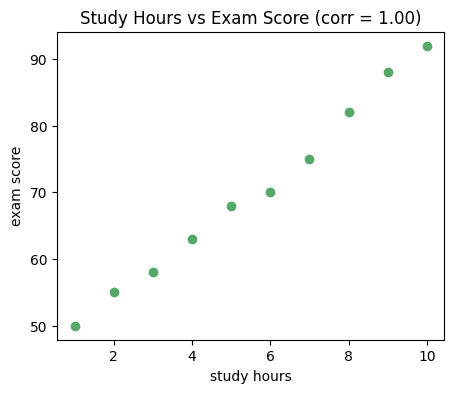

In [4]:
study_hours = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
exam_score = np.array([50, 55, 58, 63, 68, 70, 75, 82, 88, 92])

correlation = np.corrcoef(study_hours, exam_score)[0, 1]
print(f"Correlation between study hours and exam score: {correlation:.3f}")

plt.figure(figsize=(5, 4))
plt.scatter(study_hours, exam_score, color="#55A868")
plt.title(f"Study Hours vs Exam Score (corr = {correlation:.2f})")
plt.xlabel("study hours")
plt.ylabel("exam score")
plt.show()

Correlation is basically +1, makes sense since I made the numbers almost perfectly linear. Real data will obviously be messier, but at least I get *what* the number measures (strength + direction of a linear relationship, not causation — writing that down because I know I'll forget).

Last for today: conditional probability + Bayes. Used the classic medical test example because it's the one that finally made Bayes click for me.

**Setup:** A disease affects 1% of people. A test is 95% accurate for people who have the disease (true positive rate), and gives a false positive 5% of the time for people who don't have it.

**Question:** If someone tests positive, what's the actual probability they have the disease?

In [11]:
# Bayes' theorem: P(Disease | Positive) = P(Positive | Disease) * P(Disease) / P(Positive)

p_disease = 0.01
p_positive_given_disease = 0.95         # true positive rate
p_positive_given_no_disease = 0.05      # false positive rate
p_no_disease = 1 - p_disease

# P(Positive) = P(Pos|Disease)*P(Disease) + P(Pos|NoDisease)*P(NoDisease)
p_positive = (p_positive_given_disease * p_disease) + (p_positive_given_no_disease * p_no_disease)

p_disease_given_positive = (p_positive_given_disease * p_disease) / p_positive

print(f"P(Positive) overall: {p_positive:.4f}")
print(f"P(Disease | Positive test): {p_disease_given_positive:.4f}  -> about {p_disease_given_positive*100:.1f}%")

P(Positive) overall: 0.0590
P(Disease | Positive test): 0.1610  -> about 16.1%


Wait, WHAT. Even with a positive test, there's only about a **16%** chance the person actually has the disease?! Had to sit with this for a solid ten minutes.

**Why this happens (writing it out so future-me remembers):** the disease is so rare (1%) that most of the population is healthy, so even a small 5% false-positive rate on that huge healthy group produces way more false alarms than true detections from the small 1% who are actually sick. This is exactly why class imbalance matters for ML metrics too — connects straight back to why I picked recall/F1/PR-AUC over accuracy on Day 1. Nice to see it connect.
